In [1]:
# Sinkronisasi dengan drive
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [2]:
# Import semua library yang dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
# Read file csv
import pandas as pd

df = pd.read_csv('/content/gdrive/MyDrive/SEMESTER 7/Machine Learning/praktikum03/datasets/tugas/day.csv', sep=',')
df.head()


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [4]:
# Melihat informasi umum tentang dataset
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [5]:
# Menampilkan statistik deskriptif
df.describe()


,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [6]:
# Menghapus kolom yang tidak digunakan
df1 = df.drop(['instant', 'dteday', 'casual', 'registered'], axis=1)

# Mengecek apakah ada missing value
df1.isnull().sum()


,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0
atemp,0
hum,0


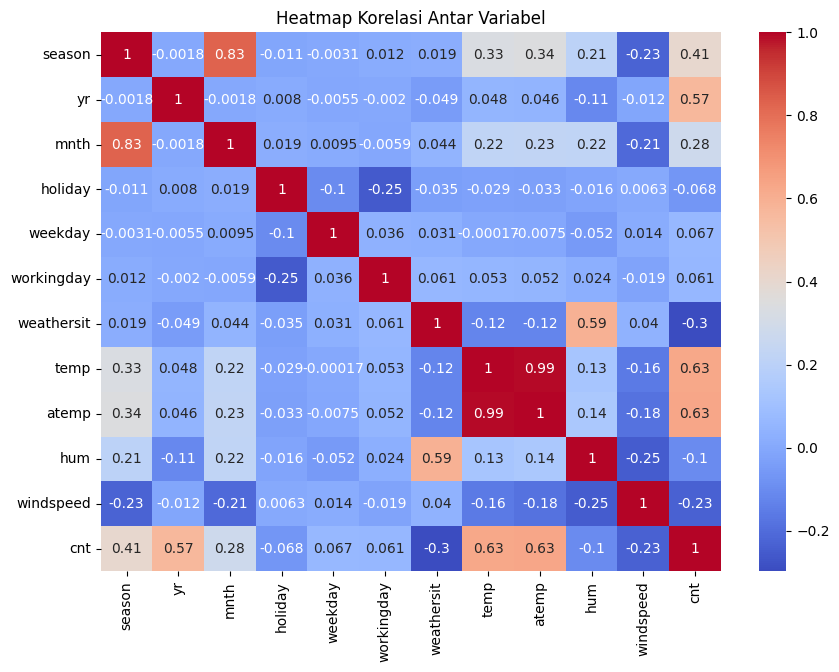

,cnt
cnt,1.000000
atemp,0.631066
temp,0.627494
yr,0.566710
season,0.406100
mnth,0.279977
weekday,0.067443
workingday,0.061156
holiday,-0.068348
hum,-0.100659


In [7]:
# Membuat matriks korelasi
corr_matrix = df1.corr()

# Visualisasi heatmap korelasi
plt.figure(figsize=(10,7))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Heatmap Korelasi Antar Variabel")
plt.show()

# Menampilkan korelasi tiap variabel terhadap 'cnt'
corr_matrix['cnt'].sort_values(ascending=False)


In [8]:
# Variabel dependen (target)
Y = df1['cnt']

# Variabel independen (semua kolom selain 'cnt')
X = df1.drop(['cnt'], axis=1)

# Menampilkan nama-nama fitur yang digunakan
X.columns


Index(['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday',
       'weathersit', 'temp', 'atemp', 'hum', 'windspeed'],
      dtype='object')

In [9]:
# Membagi dataset menjadi 80% train dan 20% test
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print("Jumlah data training:", len(X_train))
print("Jumlah data testing:", len(X_test))


Jumlah data training: 584
Jumlah data testing: 147


In [10]:
# Menambahkan konstanta untuk model OLS
X_train_sm = sm.add_constant(X_train)

# Melatih model menggunakan OLS (Ordinary Least Squares)
model = sm.OLS(Y_train, X_train_sm).fit()

# Menampilkan ringkasan hasil regresi
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.791
Model:                            OLS   Adj. R-squared:                  0.787
Method:                 Least Squares   F-statistic:                     196.9
Date:                Sun, 12 Oct 2025   Prob (F-statistic):          2.56e-186
Time:                        10:21:13   Log-Likelihood:                -4784.9
No. Observations:                 584   AIC:                             9594.
Df Residuals:                     572   BIC:                             9646.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1248.3209    272.690      4.578      0.0

In [11]:
# Evaluasi model pada data testing
X_test_sm = sm.add_constant(X_test)
Y_pred = model.predict(X_test_sm)

# Hitung metrik evaluasi
mae  = mean_absolute_error(Y_test, Y_pred)
mse  = mean_squared_error(Y_test, Y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(Y_test, Y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")


Mean Absolute Error (MAE): 617.39
Mean Squared Error (MSE): 691035.01
Root Mean Squared Error (RMSE): 831.29
R² Score: 0.8277


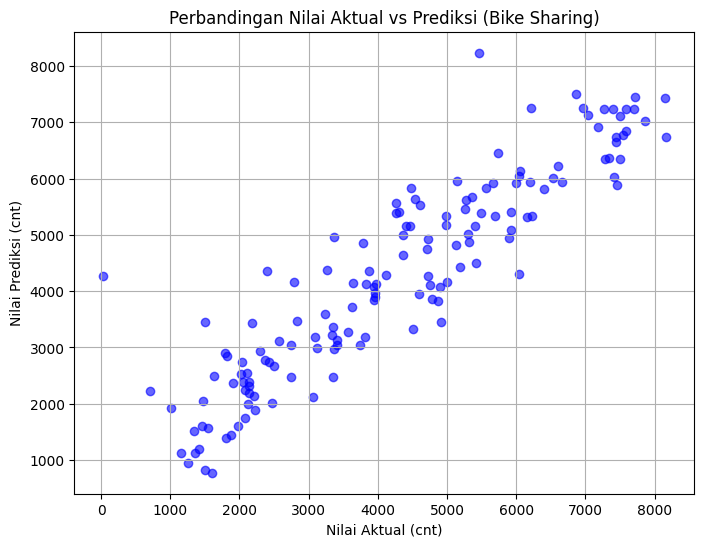

In [12]:
plt.figure(figsize=(8,6))
plt.scatter(Y_test, Y_pred, alpha=0.6, color='blue')
plt.xlabel("Nilai Aktual (cnt)")
plt.ylabel("Nilai Prediksi (cnt)")
plt.title("Perbandingan Nilai Aktual vs Prediksi (Bike Sharing)")
plt.grid(True)
plt.show()


In [13]:
# Menampilkan koefisien regresi dalam bentuk tabel
coef_df = pd.DataFrame({
    'Variabel': ['const'] + list(X.columns),
    'Koefisien': model.params.values
})
coef_df


,Variabel,Koefisien
0,const,1248.320928
1,season,524.722536
2,yr,2023.997547
3,mnth,-38.444658
4,holiday,-391.550766
5,weekday,72.937003
6,workingday,160.804892
7,weathersit,-632.856284
8,temp,2097.247836
9,atemp,3488.042179


In [14]:
print("Model Multiple Linear Regression berhasil dibangun.")
print(f"Nilai R² = {r2:.3f} menunjukkan bahwa sekitar {r2*100:.1f}% variasi jumlah penyewaan sepeda dapat dijelaskan oleh variabel-variabel independen yang digunakan.")


Model Multiple Linear Regression berhasil dibangun.
Nilai R² = 0.828 menunjukkan bahwa sekitar 82.8% variasi jumlah penyewaan sepeda dapat dijelaskan oleh variabel-variabel independen yang digunakan.
